# Rohrreaktor mit exothermer Reaktion 1. Ordnung

Diskretisierter Rohrreaktor (Tanks-in-Series) mit Kühlmantel.

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [4]:
class TubularReactor:

    def __init__(self,
                 n_cells=20,
                 V_reactor=1.0,
                 V_coolant=0.2,
                 k0=1e6,
                 Ea=80000.0,
                 dH=-50000.0,
                 UA=5000.0,
                 rho_r=1000.0,
                 cp_r=4180.0,
                 rho_c=1000.0,
                 cp_c=4180.0):

        self.n = n_cells

        self.Vr_cell = V_reactor / n_cells
        self.Vc_cell = V_coolant / n_cells

        self.k0 = k0
        self.Ea = Ea
        self.dH = dH
        self.UA = UA

        self.rho_r = rho_r
        self.cp_r = cp_r

        self.rho_c = rho_c
        self.cp_c = cp_c

        self.R = 8.314

    def rhs(self, t, y,
            q_r_f,
            c_A_f,
            T_r_f,
            q_c_f,
            T_c_f):

        n = self.n

        cA = y[0:n]
        Tr = y[n:2*n]
        Tc = y[2*n:3*n]

        dcA = np.zeros(n)
        dTr = np.zeros(n)
        dTc = np.zeros(n)

        for i in range(n):

            if i == 0:
                cA_in = c_A_f
                Tr_in = T_r_f
                Tc_in = T_c_f
            else:
                cA_in = cA[i-1]
                Tr_in = Tr[i-1]
                Tc_in = Tc[i-1]

            k = self.k0 * np.exp(-self.Ea / (self.R * Tr[i]))
            r = k * cA[i]

            dcA[i] = (
                q_r_f * (cA_in - cA[i]) / self.Vr_cell - r
            )

            dTr[i] = (
                q_r_f * (Tr_in - Tr[i]) / self.Vr_cell
                + (-self.dH) * r / (self.rho_r * self.cp_r)
                - self.UA * (Tr[i] - Tc[i])
                  / (self.rho_r * self.cp_r * self.Vr_cell)
            )

            dTc[i] = (
                q_c_f * (Tc_in - Tc[i]) / self.Vc_cell
                + self.UA * (Tr[i] - Tc[i])
                  / (self.rho_c * self.cp_c * self.Vc_cell)
            )

        return np.concatenate([dcA, dTr, dTc])

In [5]:
# Modellparameter

reactor = TubularReactor(
    n_cells=30,
    V_reactor=1.0,
    V_coolant=0.2
)

# Feedbedingungen

q_r_f = 0.01
c_A_f = 1000.0
T_r_f = 300.0

q_c_f = 0.02
T_c_f = 290.0

n = reactor.n

cA0 = np.full(n, c_A_f)
Tr0 = np.full(n, T_r_f)
Tc0 = np.full(n, T_c_f)

y0 = np.concatenate([cA0, Tr0, Tc0])

In [6]:
sol = solve_ivp(
    lambda t, y:
    reactor.rhs(
        t, y,
        q_r_f,
        c_A_f,
        T_r_f,
        q_c_f,
        T_c_f),
    [0, 5000],
    y0,
    method='BDF'
)

print(sol.message)

The solver successfully reached the end of the integration interval.


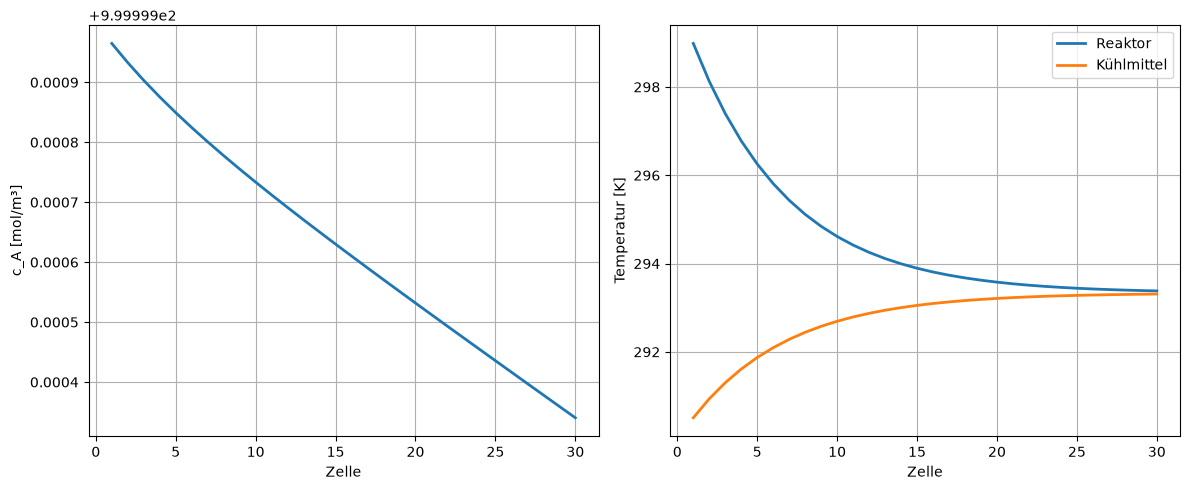

In [7]:
cA = sol.y[0:n, -1]
Tr = sol.y[n:2*n, -1]
Tc = sol.y[2*n:3*n, -1]

x = np.arange(1, n+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(x, cA, linewidth=2)
plt.xlabel('Zelle')
plt.ylabel('c_A [mol/m³]')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(x, Tr, label='Reaktor', linewidth=2)
plt.plot(x, Tc, label='Kühlmittel', linewidth=2)
plt.xlabel('Zelle')
plt.ylabel('Temperatur [K]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()